# Target24 — GRPO Full Experiment

**Запускать после** `check_hard_v2.ipynb` (данные + gold в `data_v2/`)

3 метода:
- **Step 1**: GRPO-only (curriculum + mixing)
- **Step 2**: SFT → GRPO
- **Step 3**: SRFT (SFT warmup + GRPO)

Используется **vLLM** для ускорения генерации при GRPO.

In [ ]:
!unzip grpo.zip

Archive:  grpo.zip
   creating: envs/
   creating: envs/target24/
  inflating: envs/target24/env.py    
  inflating: envs/target24/verifier.py  
   creating: envs/target24/__pycache__/
  inflating: envs/target24/__pycache__/env.cpython-310.pyc  
  inflating: envs/target24/__pycache__/verifier.cpython-310.pyc  
  inflating: check_hard_v2.ipynb     
   creating: base/
  inflating: base/data.py            
  inflating: base/env.py             
  inflating: base/verifier.py        
   creating: base/__pycache__/
  inflating: base/__pycache__/data.cpython-310.pyc  
  inflating: base/__pycache__/env.cpython-310.pyc  
  inflating: base/__pycache__/verifier.cpython-310.pyc  
   creating: data_v2/
   creating: data_v2/gold/
  inflating: data_v2/gold/gold_train_L1.jsonl  
  inflating: data_v2/gold/gold_train_L10.jsonl  
  inflating: data_v2/gold/gold_train_L2.jsonl  
  inflating: data_v2/gold/gold_train_L3.jsonl  
  inflating: data_v2/gold/gold_train_L4.jsonl  
  inflating: data_v2/gold/gold_tra

In [1]:
# Setup (раскомментировать для Colab)
!pip -q install -U pip
!pip -q install "transformers>=4.50" "trl>=0.22" datasets accelerate bitsandbytes peft
!pip -q install unsloth huggingface_hub vllm

In [ ]:
import os, sys
sys.path.insert(0, os.environ.get('PROJECT_ROOT', '.'))
from GRPO_full_experiment import *
print('Imported! USE_VLLM =', USE_VLLM)

/content/GRPO_full_experiment.py:99: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Imported! USE_VLLM = False


## Step 1: GRPO-only (curriculum + mixing)

In [ ]:
model, tokenizer = load_model_lora()
grpo_metrics = train_grpo_curriculum(model, tokenizer, tag='grpo_only', mix_previous=True)
print('GRPO-only training done!')

==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.16.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.3 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.
2026-03-06 11:48:01,905 | INFO | === grpo_only LEVEL 1 ===
2026-03-06 11:48:02,053 | INFO | Dataset: 172 (level 1)


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 2


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 172 | Num Epochs = 1 | Total steps = 80
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / validity_reward_func / mean,rewards / validity_reward_func / std,rewards / distance_reward_func / mean,rewards / distance_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
10,0.101200,0.025000,0.035355,84.450000,72.900000,96.000000,0.750000,24.900000,24.900000,24.900000,0,0,0,0,0,0.001527,0.025000,0.035355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
20,0.275200,0.035000,0.035355,66.850000,45.300000,88.400000,0.650000,7.450000,6.900000,8.000000,No Log,No Log,No Log,No Log,No Log,0.002134,0.035000,0.035355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
30,0.155200,0.025000,0.035355,75.350000,62.500000,88.200000,0.650000,24.100000,24.100000,24.100000,No Log,No Log,No Log,No Log,No Log,0.002547,0.025000,0.035355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40,0.085600,0.010000,0.014142,78.300000,60.600000,96.000000,0.700000,22.200000,22.200000,22.200000,No Log,No Log,No Log,No Log,No Log,0.002397,0.010000,0.014142,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50,0.125500,0.035000,0.035355,63.200000,42.800000,83.600000,0.550000,15.300000,14.000000,16.600000,No Log,No Log,No Log,No Log,No Log,0.004872,0.035000,0.035355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60,0.322800,0.042500,0.038891,57.350000,26.100000,88.600000,0.450000,21.100000,16.500000,25.700000,No Log,No Log,No Log,No Log,No Log,0.007172,0.042500,0.038891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
70,0.214000,0.048250,0.054094,68.800000,51.100000,86.500000,0.600000,15.800000,12.700000,18.900000,No Log,No Log,No Log,No Log,No Log,0.006735,0.035000,0.035355,0.012500,0.017678,0.000750,0.001061,0.000000,0.000000
80,0.155400,0.055000,0.035355,54.950000,37.300000,72.600000,0.400000,20.400000,18.100000,22.700000,No Log,No Log,No Log,No Log,No Log,0.014043,0.055000,0.035355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


...

Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 2


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,448 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / validity_reward_func / mean,rewards / validity_reward_func / std,rewards / distance_reward_func / mean,rewards / distance_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
10,-0.006600,0.371890,0.000381,23.000000,22.600000,23.400000,0.000000,23.000000,22.600000,23.400000,0,0,0,0,0,0.257614,0.100000,0.000000,0.250000,0.000000,0.021890,0.000381,0.000000,0.000000
20,-0.008200,0.346418,0.019685,23.000000,22.100000,23.900000,0.000000,23.000000,22.100000,23.900000,No Log,No Log,No Log,No Log,No Log,0.258117,0.100000,0.000000,0.212500,0.017678,0.033918,0.002007,0.000000,0.000000
30,0.012500,0.341692,0.019447,26.050000,23.700000,28.400000,0.000000,26.050000,23.700000,28.400000,No Log,No Log,No Log,No Log,No Log,0.397220,0.100000,0.000000,0.212500,0.017678,0.029192,0.001769,0.000000,0.000000
40,0.018500,0.341483,0.134423,29.450000,24.500000,34.400000,0.050000,26.000000,24.500000,27.500000,No Log,No Log,No Log,No Log,No Log,0.316925,0.095000,0.007071,0.175000,0.035355,0.021483,0.021286,0.050000,0.070711
50,-0.005200,0.494984,0.017906,27.600000,26.900000,28.300000,0.000000,27.600000,26.900000,28.300000,No Log,No Log,No Log,No Log,No Log,0.244491,0.100000,0.000000,0.237500,0.017678,0.057484,0.000228,0.100000,0.000000
60,0.001300,0.602560,0.017728,26.900000,26.800000,27.000000,0.000000,26.900000,26.800000,27.000000,No Log,No Log,No Log,No Log,No Log,0.242628,0.100000,0.000000,0.237500,0.017678,0.065060,0.000050,0.200000,0.000000
70,0.000300,0.360163,0.000000,24.050000,23.800000,24.300000,0.000000,24.050000,23.800000,24.300000,No Log,No Log,No Log,No Log,No Log,0.323245,0.100000,0.000000,0.250000,0.000000,0.010163,0.000000,0.000000,0.000000
80,0.000300,0.491866,0.000513,27.100000,26.900000,27.300000,0.000000,27.100000,26.900000,27.300000,No Log,No Log,No Log,No Log,No Log,0.292475,0.100000,0.000000,0.250000,0.000000,0.041866,0.000513,0.100000,0.000000
90,-0.004800,0.622977,0.089803,20.550000,20.100000,21.000000,0.000000,20.550000,20.100000,21.000000,No Log,No Log,No Log,No Log,No Log,0.640245,0.100000,0.000000,0.250000,0.000000,0.122977,0.019093,0.150000,0.070711
100,0.000500,0.495266,0.000000,27.550000,27.100000,28.000000,0.000000,27.550000,27.100000,28.000000,No Log,No Log,No Log,No Log,No Log,0.467610,0.100000,0.000000,0.250000,0.000000,0.045266,0.000000,0.100000,0.000000


2026-03-06 12:52:39,224 | INFO | Train done in 8.8 min
2026-03-06 12:52:39,725 | INFO | Saved adapter: runs_exp/grpo_only_L10/lora_adapter


  grpo_only final LoRA saved: runs_exp/grpo_only_final
GRPO-only training done!


In [ ]:
# Eval GRPO-only: pass@128 по уровням + диагностика
FastLanguageModel.for_inference(model)
for lvl in range(1, MAX_LEVEL + 1):
    r = eval_pass_at_k(model, tokenizer, lvl, tag='grpo_only')
    pk = r['pass_at_k']
    print(f"L{lvl}: pass@1={pk.get(1,0):.4f}, pass@128={pk.get(128,0):.4f}")

import json
with open(LOGS_DIR / 'grpo_only_pass_at_k.json', 'w') as f:
    json.dump({str(lvl): r['pass_at_k'] for lvl in range(1,MAX_LEVEL+1)}, f, indent=2)

del model, tokenizer
import gc; gc.collect()
import torch
if torch.cuda.is_available(): torch.cuda.empty_cache()

  grpo_only L1 [10/28] this=0/128 solved=1/10
  grpo_only L1 [20/28] this=0/128 solved=3/20

  L1 SUMMARY: 5/28 solved (pass@128=0.1786)
  Unsolved tasks (23):
    #1: numbers=['6', '1'] target=7 gold=6 + 1
    #2: numbers=['8', '8'] target=1 gold=8 / 8
    #3: numbers=['1', '7'] target=8 gold=1 + 7
    #4: numbers=['1', '1'] target=1 gold=1 / 1
    #5: numbers=['7', '4'] target=28 gold=7 * 4
    #6: numbers=['3', '8'] target=24 gold=3 * 8
    #7: numbers=['6', '1'] target=6 gold=6 * 1
    #8: numbers=['6', '5'] target=30 gold=6 * 5
    #9: numbers=['5', '3'] target=15 gold=5 * 3
    #10: numbers=['1', '8'] target=8 gold=1 * 8
    ... и ещё 13
L1: pass@1=0.1786, pass@128=0.1786
  grpo_only L2 [10/50] this=0/128 solved=1/10
  grpo_only L2 [20/50] this=0/128 solved=1/20
  grpo_only L2 [30/50] this=0/128 solved=2/30
  grpo_only L2 [40/50] this=0/128 solved=2/40
  grpo_only L2 [50/50] this=0/128 solved=4/50

  L2 SUMMARY: 4/50 solved (pass@128=0.0800)
  Unsolved tasks (46):
    #0: numbers

In [ ]:
# =========================================
# Просмотр решённых/нерешённых примеров
# =========================================
import json
from pathlib import Path

LOGS_DIR = Path("logs_exp")
tag = "grpo_only"  # или "sft_grpo", "srft"

for level in range(1, 11):
    diag_path = LOGS_DIR / f"{tag}_diag_L{level}.json"
    if not diag_path.exists():
        continue
    with open(diag_path) as f:
        diag = json.load(f)

    pk = diag.get("pass_at_k", {})
    tasks = diag.get("per_task", [])

    solved = [t for t in tasks if t["n_correct"] > 0]
    # "Уверенно решённые" = correct в >50% попыток (≈ pass@1)
    confident = [t for t in tasks if t["n_correct"] > t["n_total"] // 2]
    unsolved = [t for t in tasks if t["n_correct"] == 0]

    print(f"\n{'='*60}")
    print(f"LEVEL {level}  |  pass@1={pk.get('1',0):.4f}  pass@128={pk.get('128',0):.4f}")
    print(f"  Total: {len(tasks)} | Solved: {len(solved)} | Confident: {len(confident)} | Unsolved: {len(unsolved)}")

    if confident:
        print(f"\n  ✅ Уверенно решённые (>50% correct, ≈ pass@1):")
        for t in confident:
            print(f"    nums={t['numbers']} target={t['target']} "
                  f"gold={t['gold_expr']}  [{t['n_correct']}/{t['n_total']}]")

    barely = [t for t in solved if t not in confident]
    if barely:
        print(f"\n  🟡 Еле решённые (1-50% correct, pass@128 но не pass@1):")
        for t in barely:
            print(f"    nums={t['numbers']} target={t['target']} "
                  f"gold={t['gold_expr']}  [{t['n_correct']}/{t['n_total']}]")

    if unsolved:
        print(f"\n  ❌ Нерешённые ({len(unsolved)}):")
        for t in unsolved[:5]:
            print(f"    nums={t['numbers']} target={t['target']} "
                  f"gold={t['gold_expr']}")
        if len(unsolved) > 5:
            print(f"    ... и ещё {len(unsolved)-5}")



LEVEL 1  |  pass@1=0.1786  pass@128=0.1786
  Total: 28 | Solved: 5 | Confident: 5 | Unsolved: 23

  ✅ Уверенно решённые (>50% correct, ≈ pass@1):
    nums=['4', '4'] target=0 gold=4 - 4  [128/128]
    nums=['6', '2'] target=4 gold=6 - 2  [128/128]
    nums=['8', '7'] target=1 gold=8 - 7  [128/128]
    nums=['3', '3'] target=0 gold=3 - 3  [128/128]
    nums=['2', '1'] target=1 gold=2 - 1  [128/128]

  ❌ Нерешённые (23):
    nums=['6', '1'] target=7 gold=6 + 1
    nums=['8', '8'] target=1 gold=8 / 8
    nums=['1', '7'] target=8 gold=1 + 7
    nums=['1', '1'] target=1 gold=1 / 1
    nums=['7', '4'] target=28 gold=7 * 4
    ... и ещё 18

LEVEL 2  |  pass@1=0.0800  pass@128=0.0800
  Total: 50 | Solved: 4 | Confident: 4 | Unsolved: 46

  ✅ Уверенно решённые (>50% correct, ≈ pass@1):
    nums=['8', '7', '9'] target=10 gold=8 - 7 + 9  [128/128]
    nums=['5', '5', '2'] target=2 gold=5 / 5 * 2  [128/128]
    nums=['5', '1', '4'] target=8 gold=5 - 1 + 4  [128/128]
    nums=['4', '2', '8'] targe

In [ ]:
import shutil, os
os.makedirs('results', exist_ok=True)
shutil.copytree('logs_exp', 'results/logs_exp', dirs_exist_ok=True)
shutil.copytree('runs_exp', 'results/runs_exp', dirs_exist_ok=True)
shutil.make_archive('results', 'zip', '.', 'results')
from google.colab import files
files.download('results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

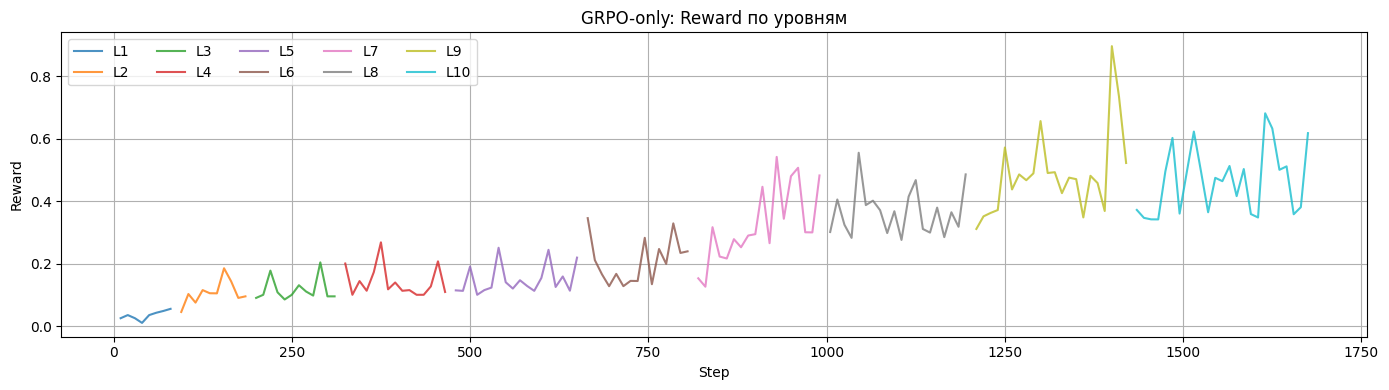

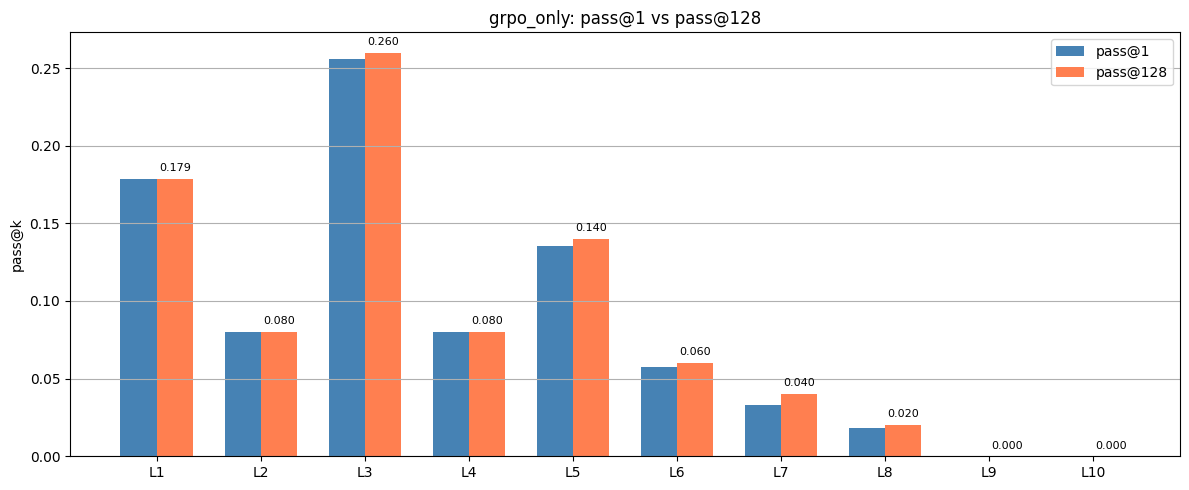


Сводка:
  L1: pass@1=0.1786  pass@128=0.1786
  L2: pass@1=0.0800  pass@128=0.0800
  L3: pass@1=0.2556  pass@128=0.2600
  L4: pass@1=0.0800  pass@128=0.0800
  L5: pass@1=0.1352  pass@128=0.1400
  L6: pass@1=0.0578  pass@128=0.0600
  L7: pass@1=0.0333  pass@128=0.0400
  L8: pass@1=0.0181  pass@128=0.0200
  L9: pass@1=0.0000  pass@128=0.0000
  L10: pass@1=0.0000  pass@128=0.0000


In [ ]:
import matplotlib.pyplot as plt
import json, numpy as np
from pathlib import Path

LOGS_DIR = Path("logs_exp")

# 1. Reward curves по уровням
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_title("GRPO-only: Reward по уровням")
offset = 0
for lvl in range(1, 11):
    p = LOGS_DIR / f"grpo_only_metrics_L{lvl}.jsonl"
    if not p.exists(): continue
    steps, rewards = [], []
    for line in open(p):
        rec = json.loads(line)
        if "reward" in rec:
            steps.append(rec["step"] + offset)
            rewards.append(rec["reward"])
    if steps:
        ax.plot(steps, rewards, label=f"L{lvl}", alpha=0.8)
        offset = steps[-1] + 5
ax.set_xlabel("Step"); ax.set_ylabel("Reward"); ax.legend(ncol=5); ax.grid(True)
plt.tight_layout(); plt.show()

# 2. pass@128 bar chart
tag = "grpo_only"

# Читаем pass@k из diag-файлов (каждый сохранён правильно)
levels_list, pk1, pk128 = [], [], []
for lvl in range(1, 11):
    p = LOGS_DIR / f"{tag}_diag_L{lvl}.json"
    if not p.exists(): continue
    with open(p) as f:
        d = json.load(f)
    pk = d.get("pass_at_k", {})
    levels_list.append(f"L{lvl}")
    pk1.append(pk.get("1", 0))
    pk128.append(pk.get("128", 0))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(levels_list))
w = 0.35
ax.bar(x - w/2, pk1, w, label='pass@1', color='steelblue')
ax.bar(x + w/2, pk128, w, label='pass@128', color='coral')
ax.set_xticks(x); ax.set_xticklabels(levels_list)
ax.set_ylabel('pass@k'); ax.set_title(f'{tag}: pass@1 vs pass@128')
ax.legend(); ax.grid(axis='y')
for i in range(len(levels_list)):
    ax.text(i + w/2, pk128[i] + 0.005, f"{pk128[i]:.3f}", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print("\nСводка:")
for l, p1, p128 in zip(levels_list, pk1, pk128):
    print(f"  {l}: pass@1={p1:.4f}  pass@128={p128:.4f}")



## Step 2: SFT → GRPO

In [ ]:
!unzip grpo.zip

Archive:  grpo.zip
   creating: envs/
   creating: envs/target24/
  inflating: envs/target24/env.py    
  inflating: envs/target24/verifier.py  
   creating: envs/target24/__pycache__/
  inflating: envs/target24/__pycache__/env.cpython-310.pyc  
  inflating: envs/target24/__pycache__/verifier.cpython-310.pyc  
  inflating: check_hard_v2.ipynb     
  inflating: GRPO_full_experiment.ipynb  
  inflating: GRPO_full_experiment.py  
   creating: base/
  inflating: base/data.py            
  inflating: base/env.py             
  inflating: base/verifier.py        
   creating: base/__pycache__/
  inflating: base/__pycache__/data.cpython-310.pyc  
  inflating: base/__pycache__/env.cpython-310.pyc  
  inflating: base/__pycache__/verifier.cpython-310.pyc  
   creating: data_v2/
   creating: data_v2/gold/
  inflating: data_v2/gold/gold_train_L1.jsonl  
  inflating: data_v2/gold/gold_train_L10.jsonl  
  inflating: data_v2/gold/gold_train_L2.jsonl  
  inflating: data_v2/gold/gold_train_L3.jsonl  
 

In [ ]:
import os, sys
sys.path.insert(0, os.environ.get('PROJECT_ROOT', '.'))
from GRPO_full_experiment import *
print('Imported! USE_VLLM =', USE_VLLM)


/content/GRPO_full_experiment.py:101: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Imported! USE_VLLM = False


In [ ]:
model, tokenizer = load_model_lora()
print('Phase 1: SFT on gold trajectories')
train_sft(model, tokenizer, tag='sft_phase')
print('Phase 2: GRPO curriculum')
train_grpo_curriculum(model, tokenizer, tag='sft_grpo', mix_previous=True)
print('SFT→GRPO done!')

==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.16.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 2


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,448 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / validity_reward_func / mean,rewards / validity_reward_func / std,rewards / distance_reward_func / mean,rewards / distance_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
10,0.000600,0.827556,0.091138,47.800000,47.800000,47.800000,0.000000,47.800000,47.800000,47.800000,0,0,0,0,0,0.642666,0.200000,0.000000,0.250000,0.000000,0.127556,0.020428,0.250000,0.070711
20,0.000600,0.620575,0.011170,48.900000,48.900000,48.900000,0.000000,48.900000,48.900000,48.900000,No Log,No Log,No Log,No Log,No Log,0.631839,0.200000,0.000000,0.250000,0.000000,0.070575,0.011170,0.100000,0.000000
30,0.000600,0.713405,0.097156,50.500000,50.500000,50.500000,0.000000,50.500000,50.500000,50.500000,No Log,No Log,No Log,No Log,No Log,0.619144,0.200000,0.000000,0.250000,0.000000,0.113405,0.026445,0.150000,0.070711
40,0.000900,0.845204,0.001213,53.750000,53.700000,53.800000,0.000000,53.750000,53.700000,53.800000,No Log,No Log,No Log,No Log,No Log,0.584521,0.200000,0.000000,0.250000,0.000000,0.095204,0.001213,0.300000,0.000000
50,0.000500,0.603516,0.003256,58.600000,58.600000,58.600000,0.000000,58.600000,58.600000,58.600000,No Log,No Log,No Log,No Log,No Log,0.529205,0.200000,0.000000,0.250000,0.000000,0.053516,0.003256,0.100000,0.000000
60,0.000600,0.657446,0.093552,54.500000,54.500000,54.500000,0.000000,54.500000,54.500000,54.500000,No Log,No Log,No Log,No Log,No Log,0.571024,0.200000,0.000000,0.250000,0.000000,0.057446,0.022842,0.150000,0.070711
70,0.000600,0.670826,0.092078,50.000000,50.000000,50.000000,0.000000,50.000000,50.000000,50.000000,No Log,No Log,No Log,No Log,No Log,0.606882,0.200000,0.000000,0.250000,0.000000,0.070826,0.021368,0.150000,0.070711
80,0.003100,0.452902,0.040837,55.650000,55.400000,55.900000,0.000000,55.650000,55.400000,55.900000,No Log,No Log,No Log,No Log,No Log,0.631870,0.200000,0.000000,0.225000,0.035355,0.027902,0.005482,0.000000,0.000000
90,0.001500,0.768655,0.001414,43.700000,43.600000,43.800000,0.000000,43.700000,43.600000,43.800000,No Log,No Log,No Log,No Log,No Log,0.721410,0.200000,0.000000,0.250000,0.000000,0.118655,0.001414,0.200000,0.000000
100,-0.000200,0.461653,0.002916,56.750000,56.700000,56.800000,0.000000,56.750000,56.700000,56.800000,No Log,No Log,No Log,No Log,No Log,0.565381,0.200000,0.000000,0.250000,0.000000,0.011653,0.002916,0.000000,0.000000


2026-03-06 22:11:00,256 | INFO | Train done in 15.3 min
2026-03-06 22:11:01,486 | INFO | Saved adapter: runs_sft_grpo/sft_grpo_L10/lora_adapter


  sft_grpo final LoRA saved: runs_sft_grpo/sft_grpo_final
SFT→GRPO done!


In [ ]:
import shutil
from google.colab import files

# Архивируем всё что есть
shutil.make_archive('sft_grpo_results', 'zip', '.', 'logs_sft_grpo')
shutil.make_archive('sft_grpo_runs', 'zip', '.', 'runs_sft_grpo')

files.download('sft_grpo_results.zip')
files.download('sft_grpo_runs.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
FastLanguageModel.for_inference(model)
for lvl in range(1, MAX_LEVEL + 1):
    r = eval_pass_at_k(model, tokenizer, lvl, tag='sft_grpo')
    pk = r['pass_at_k']
    print(f"L{lvl}: pass@1={pk.get(1,0):.4f}, pass@128={pk.get(128,0):.4f}")

with open(LOGS_DIR / 'sft_grpo_pass_at_k.json', 'w') as f:
    json.dump({str(lvl): r['pass_at_k'] for lvl in range(1,MAX_LEVEL+1)}, f, indent=2)

del model, tokenizer; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

  sft_grpo L1 [10/28] this=0/128 solved=9/10
  sft_grpo L1 [20/28] this=128/128 solved=16/20

  L1 SUMMARY: 23/28 solved (pass@128=0.8214)
  Unsolved tasks (5):
    #9: numbers=['5', '3'] target=15 gold=5 * 3
    #10: numbers=['1', '8'] target=8 gold=1 * 8
    #11: numbers=['2', '7'] target=14 gold=2 * 7
    #18: numbers=['4', '3'] target=12 gold=4 * 3
    #22: numbers=['2', '4'] target=8 gold=2 * 4
L1: pass@1=0.6364, pass@128=0.8214
  sft_grpo L2 [10/50] this=0/128 solved=3/10
  sft_grpo L2 [20/50] this=0/128 solved=9/20
  sft_grpo L2 [30/50] this=7/128 solved=12/30
  sft_grpo L2 [40/50] this=128/128 solved=20/40
  sft_grpo L2 [50/50] this=0/128 solved=24/50

  L2 SUMMARY: 24/50 solved (pass@128=0.4800)
  Unsolved tasks (26):
    #1: numbers=['3', '5', '2'] target=13 gold=3 * 5 - 2
    #2: numbers=['5', '5', '1'] target=0 gold=5 - 5 * 1
    #4: numbers=['3', '7', '2'] target=17 gold=3 + 7 * 2
    #5: numbers=['5', '9', '8'] target=53 gold=5 * 9 + 8
    #7: numbers=['5', '1', '3'] targ

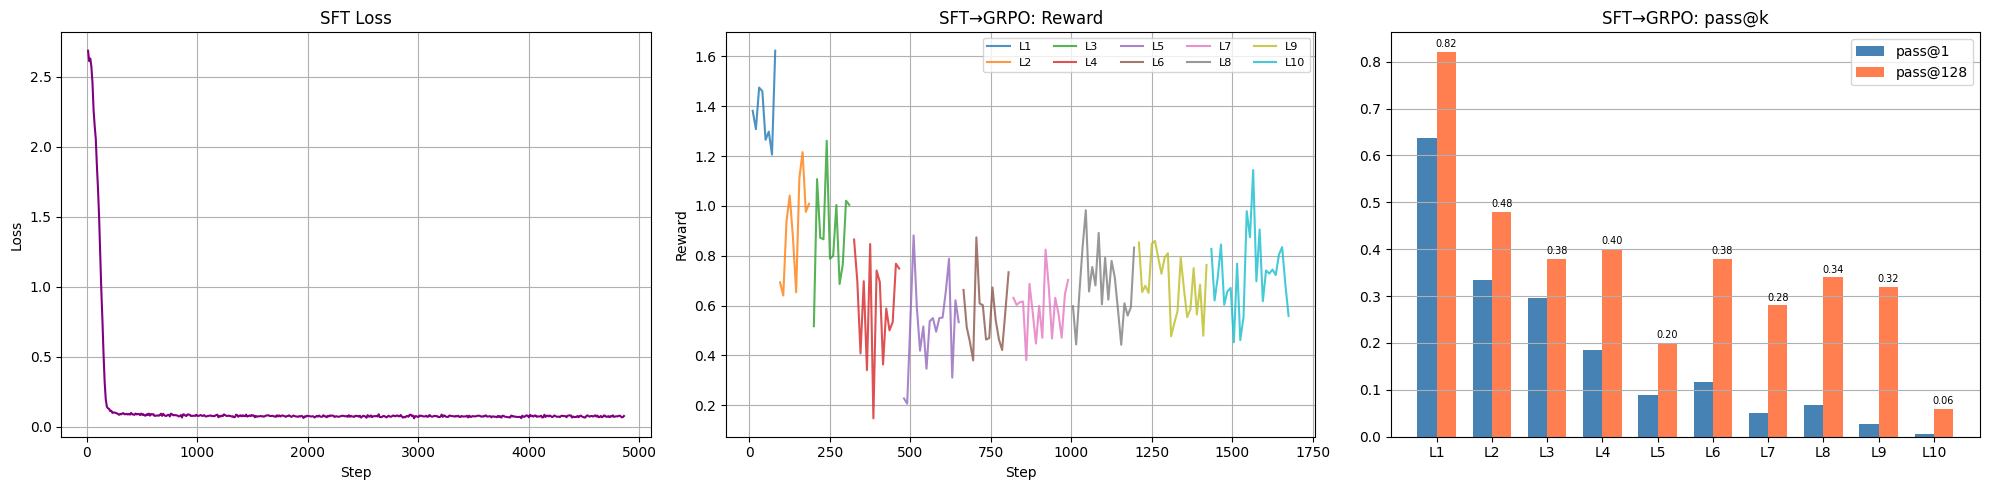


Сводка SFT→GRPO:
  L1: pass@1=0.6364  pass@128=0.8214
  L2: pass@1=0.3336  pass@128=0.4800
  L3: pass@1=0.2967  pass@128=0.3800
  L4: pass@1=0.1847  pass@128=0.4000
  L5: pass@1=0.0880  pass@128=0.2000
  L6: pass@1=0.1166  pass@128=0.3800
  L7: pass@1=0.0508  pass@128=0.2800
  L8: pass@1=0.0669  pass@128=0.3400
  L9: pass@1=0.0266  pass@128=0.3200
  L10: pass@1=0.0050  pass@128=0.0600


In [ ]:
import matplotlib.pyplot as plt
import json, numpy as np
from pathlib import Path

LOGS = Path("logs_sft_grpo")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. SFT Loss curve
ax = axes[0]
ax.set_title("SFT Loss")
p = LOGS / "sft_phase_metrics.jsonl"
if p.exists():
    steps, losses = [], []
    for line in open(p):
        rec = json.loads(line)
        if "loss" in rec:
            steps.append(rec["step"])
            losses.append(rec["loss"])
    ax.plot(steps, losses, color='purple')
    ax.set_xlabel("Step"); ax.set_ylabel("Loss"); ax.grid(True)

# 2. GRPO Reward curves по уровням
ax = axes[1]
ax.set_title("SFT→GRPO: Reward")
offset = 0
for lvl in range(1, 11):
    p = LOGS / f"sft_grpo_metrics_L{lvl}.jsonl"
    if not p.exists(): continue
    steps, rewards = [], []
    for line in open(p):
        rec = json.loads(line)
        if "reward" in rec:
            steps.append(rec["step"] + offset)
            rewards.append(rec["reward"])
    if steps:
        ax.plot(steps, rewards, label=f"L{lvl}", alpha=0.8)
        offset = steps[-1] + 5
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.legend(ncol=5, fontsize=8); ax.grid(True)

# 3. pass@1 vs pass@128
ax = axes[2]
ax.set_title("SFT→GRPO: pass@k")
levels_list, pk1, pk128 = [], [], []
for lvl in range(1, 11):
    dp = LOGS / f"sft_grpo_diag_L{lvl}.json"
    if not dp.exists(): continue
    with open(dp) as f:
        d = json.load(f)
    pk = d.get("pass_at_k", {})
    levels_list.append(f"L{lvl}")
    pk1.append(pk.get("1", 0))
    pk128.append(pk.get("128", 0))

if levels_list:
    x = np.arange(len(levels_list))
    w = 0.35
    ax.bar(x - w/2, pk1, w, label='pass@1', color='steelblue')
    ax.bar(x + w/2, pk128, w, label='pass@128', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(levels_list)
    ax.legend(); ax.grid(axis='y')
    for i in range(len(levels_list)):
        ax.text(i + w/2, pk128[i] + 0.01, f"{pk128[i]:.2f}", ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(LOGS / "sft_grpo_analysis.png", dpi=150)
plt.show()

# Сводка
print("\nСводка SFT→GRPO:")
for l, p1, p128 in zip(levels_list, pk1, pk128):
    print(f"  {l}: pass@1={p1:.4f}  pass@128={p128:.4f}")


In [ ]:
import shutil
from pathlib import Path
from google.colab import files

# Архивируем логи (включая diag-файлы и графики)
shutil.make_archive('sft_grpo_logs', 'zip', '.', 'logs_sft_grpo')
files.download('sft_grpo_logs.zip')

# Адаптеры (если нужны)
# shutil.make_archive('sft_grpo_runs', 'zip', '.', 'runs_sft_grpo')
# files.download('sft_grpo_runs.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 3: SRFT

In [ ]:
!unzip grpo.zip

Archive:  grpo.zip
   creating: envs/
   creating: envs/target24/
  inflating: envs/target24/env.py    
  inflating: envs/target24/verifier.py  
   creating: envs/target24/__pycache__/
  inflating: envs/target24/__pycache__/env.cpython-310.pyc  
  inflating: envs/target24/__pycache__/verifier.cpython-310.pyc  
  inflating: check_hard_v2.ipynb     
  inflating: GRPO_full_experiment.ipynb  
  inflating: GRPO_full_experiment.py  
   creating: base/
  inflating: base/data.py            
  inflating: base/env.py             
  inflating: base/verifier.py        
   creating: base/__pycache__/
  inflating: base/__pycache__/data.cpython-310.pyc  
  inflating: base/__pycache__/env.cpython-310.pyc  
  inflating: base/__pycache__/verifier.cpython-310.pyc  
   creating: data_v2/
   creating: data_v2/gold/
  inflating: data_v2/gold/gold_train_L1.jsonl  
  inflating: data_v2/gold/gold_train_L10.jsonl  
  inflating: data_v2/gold/gold_train_L2.jsonl  
  inflating: data_v2/gold/gold_train_L3.jsonl  
 

In [ ]:
!pip install transformers

In [2]:
import os, sys
sys.path.insert(0, os.environ.get('PROJECT_ROOT', '.'))
from GRPO_full_experiment import *
print('Imported! USE_VLLM =', USE_VLLM)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Imported! USE_VLLM = False


In [ ]:
model, tokenizer = load_model_lora()
train_srft(model, tokenizer, tag='srft', mix_previous=True)
print('SRFT done!')

==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.17.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 2


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,448 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / validity_reward_func / mean,rewards / validity_reward_func / std,rewards / distance_reward_func / mean,rewards / distance_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
10,0.041300,0.371590,0.146013,49.400000,42.500000,56.300000,0.100000,46.450000,42.500000,50.400000,0,0,0,0,0,0.652985,0.070000,0.014142,0.100000,0.035355,0.051590,0.025805,0.150000,0.070711
20,-0.064000,0.336894,0.267053,53.800000,44.800000,62.800000,0.100000,52.100000,44.800000,59.400000,No Log,No Log,No Log,No Log,No Log,0.550122,0.082500,0.024749,0.112500,0.053033,0.041894,0.047850,0.100000,0.141421
30,-0.006900,0.123129,0.079555,57.650000,46.800000,68.500000,0.200000,43.300000,37.200000,49.400000,No Log,No Log,No Log,No Log,No Log,0.693892,0.055000,0.021213,0.062500,0.053033,0.005629,0.005309,0.000000,0.000000
40,0.031700,0.174805,0.064973,67.500000,56.100000,78.900000,0.250000,50.950000,46.500000,55.400000,No Log,No Log,No Log,No Log,No Log,0.563917,0.065000,0.021213,0.100000,0.035355,0.009805,0.008405,0.000000,0.000000
50,-0.051100,0.093874,0.104473,64.800000,52.600000,77.000000,0.150000,60.800000,52.600000,69.000000,No Log,No Log,No Log,No Log,No Log,0.727413,0.055000,0.049497,0.037500,0.053033,0.001374,0.001943,0.000000,0.000000
60,0.003100,0.193234,0.137283,64.200000,57.900000,70.500000,0.200000,53.500000,48.300000,58.700000,No Log,No Log,No Log,No Log,No Log,0.599573,0.060000,0.028284,0.062500,0.017678,0.020734,0.020610,0.050000,0.070711
70,0.005900,0.382099,0.181513,53.650000,43.200000,64.100000,0.050000,50.300000,43.200000,57.400000,No Log,No Log,No Log,No Log,No Log,0.582166,0.080000,0.014142,0.100000,0.070711,0.052099,0.025950,0.150000,0.070711
80,0.052900,0.236419,0.226817,58.050000,52.900000,63.200000,0.150000,46.450000,43.300000,49.600000,No Log,No Log,No Log,No Log,No Log,0.670858,0.065000,0.021213,0.100000,0.106066,0.021419,0.028828,0.050000,0.070711
90,0.027300,0.273912,0.224782,54.000000,43.400000,64.600000,0.100000,48.850000,43.400000,54.300000,No Log,No Log,No Log,No Log,No Log,0.592855,0.075000,0.021213,0.112500,0.088388,0.036412,0.044470,0.050000,0.070711
100,-0.017800,0.170125,0.125435,66.500000,55.300000,77.700000,0.200000,61.300000,55.300000,67.300000,No Log,No Log,No Log,No Log,No Log,0.558971,0.077500,0.031820,0.087500,0.088388,0.005125,0.005227,0.000000,0.000000


2026-03-07 17:27:12,488 | INFO | Train done in 10.3 min


  srft final LoRA saved: runs_sft_grpo/srft_final
SRFT done!


In [ ]:
FastLanguageModel.for_inference(model)
for lvl in range(1, MAX_LEVEL + 1):
    r = eval_pass_at_k(model, tokenizer, lvl, tag='srft')
    pk = r['pass_at_k']
    print(f"L{lvl}: pass@1={pk.get(1,0):.4f}, pass@128={pk.get(128,0):.4f}")

with open(LOGS_DIR / 'srft_pass_at_k.json', 'w') as f:    json.dump({str(lvl): r['pass_at_k'] for lvl in range(1,MAX_LEVEL+1)}, f, indent=2)

del model, tokenizer; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

  srft L1 [10/28] this=18/128 solved=9/10
  srft L1 [20/28] this=60/128 solved=19/20

  L1 SUMMARY: 27/28 solved (pass@128=0.9643)
  Unsolved tasks (1):
    #4: numbers=['1', '1'] target=1 gold=1 / 1
L1: pass@1=0.2983, pass@128=0.9643
  srft L2 [10/50] this=0/128 solved=6/10
  srft L2 [20/50] this=36/128 solved=15/20
  srft L2 [30/50] this=0/128 solved=21/30
  srft L2 [40/50] this=0/128 solved=29/40
  srft L2 [50/50] this=33/128 solved=36/50

  L2 SUMMARY: 36/50 solved (pass@128=0.7200)
  Unsolved tasks (14):
    #0: numbers=['5', '5', '4'] target=5 gold=5 / 5 + 4
    #6: numbers=['8', '7', '9'] target=10 gold=8 - 7 + 9
    #7: numbers=['5', '1', '3'] target=3 gold=5 + 1 - 3
    #9: numbers=['9', '6', '5'] target=49 gold=9 * 6 - 5
    #18: numbers=['6', '6', '2'] target=9 gold=6 + 6 / 2
    #20: numbers=['4', '1', '4'] target=1 gold=4 + 1 - 4
    #21: numbers=['5', '2', '1'] target=9 gold=5 * 2 - 1
    #26: numbers=['9', '5', '2'] target=43 gold=9 * 5 - 2
    #29: numbers=['6', '1', '7

In [ ]:
import shutil
import time
from pathlib import Path

logs_dir = Path(LOGS_DIR)
#runs_dir = Path(RUNS_DIR)

stamp = time.strftime("%Y%m%d_%H%M%S")
logs_zip = f"srft_logs_{stamp}"
#runs_zip = f"srft_runs_{stamp}"

if logs_dir.exists():
    shutil.make_archive(logs_zip, "zip", root_dir=".", base_dir=str(logs_dir))
    print(f"Created: {logs_zip}.zip")
else:
    print(f"Missing logs dir: {logs_dir}")

#if runs_dir.exists():
#    shutil.make_archive(runs_zip, "zip", root_dir=".", base_dir=str(runs_dir))
#    print(f"Created: {runs_zip}.zip")
#else:
#    print(f"Missing runs dir: {runs_dir}")

In [ ]:
import matplotlib.pyplot as plt
import json, numpy as np
from pathlib import Path

# Папка с логами та же, так как LOGS_DIR = Path("logs_sft_grpo")
LOGS = Path("logs_sft_grpo")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. SRFT (SFT Warmup) Loss curve
ax = axes[0]
ax.set_title("SRFT: SFT Warmup Loss")
p = LOGS / "srft_sft_warmup_metrics.jsonl"
if p.exists():
    steps, losses = [], []
    for line in open(p, encoding="utf-8"):
        rec = json.loads(line)
        if "loss" in rec:
            steps.append(rec["step"])
            losses.append(rec["loss"])
    ax.plot(steps, losses, color='purple')
    ax.set_xlabel("Step"); ax.set_ylabel("Loss"); ax.grid(True)
else:
    ax.text(0.5, 0.5, 'No SFT warmup data found', ha='center', va='center')

# 2. SRFT Reward curves по уровням
ax = axes[1]
ax.set_title("SRFT: GRPO Reward")
offset = 0
for lvl in range(1, 11):
    p = LOGS / f"srft_metrics_L{lvl}.jsonl"
    if not p.exists(): continue
    steps, rewards = [], []
    for line in open(p, encoding="utf-8"):
        rec = json.loads(line)
        if "reward" in rec:
            steps.append(rec["step"] + offset)
            rewards.append(rec["reward"])
    if steps:
        ax.plot(steps, rewards, label=f"L{lvl}", alpha=0.8)
        offset = steps[-1] + 5
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.legend(ncol=5, fontsize=8); ax.grid(True)

# 3. pass@1 vs pass@128 (SRFT)
ax = axes[2]
ax.set_title("SRFT: pass@k")
levels_list, pk1, pk128 = [], [], []
for lvl in range(1, 11):
    dp = LOGS / f"srft_diag_L{lvl}.json"
    if not dp.exists(): continue
    with open(dp, encoding="utf-8") as f:
        d = json.load(f)
    pk = d.get("pass_at_k", {})
    levels_list.append(f"L{lvl}")
    pk1.append(pk.get("1", 0))
    pk128.append(pk.get("128", 0))

if levels_list:
    x = np.arange(len(levels_list))
    w = 0.35
    ax.bar(x - w/2, pk1, w, label='pass@1', color='steelblue')
    ax.bar(x + w/2, pk128, w, label='pass@128', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(levels_list)
    ax.legend(); ax.grid(axis='y')
    for i in range(len(levels_list)):
        ax.text(i + w/2, pk128[i] + 0.01, f"{pk128[i]:.2f}", ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(LOGS / "srft_analysis.png", dpi=150)
plt.show()

# Сводка
print("\nСводка SRFT:")
for l, p1, p128 in zip(levels_list, pk1, pk128):
    print(f"  {l}: pass@1={p1:.4f}  pass@128={p128:.4f}")


In [ ]:
import shutil
import time
from pathlib import Path

logs_dir = Path(LOGS_DIR)
#runs_dir = Path(RUNS_DIR)

stamp = time.strftime("%Y%m%d_%H%M%S")
logs_zip = f"srft_logs_{stamp}"
#runs_zip = f"srft_runs_{stamp}"

if logs_dir.exists():
    shutil.make_archive(logs_zip, "zip", root_dir=".", base_dir=str(logs_dir))
    print(f"Created: {logs_zip}.zip")
else:
    print(f"Missing logs dir: {logs_dir}")

#if runs_dir.exists():
#    shutil.make_archive(runs_zip, "zip", root_dir=".", base_dir=str(runs_dir))
#    print(f"Created: {runs_zip}.zip")
#else:
#    print(f"Missing runs dir: {runs_dir}")

In [ ]:
from google.colab import files

files.download(f"{logs_zip}.zip")
#files.download(f"{runs_zip}.zip")

## SRFT

In [1]:
!unzip grpo.zip

Archive:  grpo.zip
   creating: envs/
   creating: envs/target24/
  inflating: envs/target24/env.py    
  inflating: envs/target24/verifier.py  
   creating: envs/target24/__pycache__/
  inflating: envs/target24/__pycache__/env.cpython-310.pyc  
  inflating: envs/target24/__pycache__/verifier.cpython-310.pyc  
  inflating: check_hard_v2.ipynb     
  inflating: GRPO_full_experiment.ipynb  
  inflating: GRPO_full_experiment.py  
   creating: base/
  inflating: base/data.py            
  inflating: base/env.py             
  inflating: base/verifier.py        
   creating: base/__pycache__/
  inflating: base/__pycache__/data.cpython-310.pyc  
  inflating: base/__pycache__/env.cpython-310.pyc  
  inflating: base/__pycache__/verifier.cpython-310.pyc  
   creating: data_v2/
   creating: data_v2/gold/
  inflating: data_v2/gold/gold_train_L1.jsonl  
  inflating: data_v2/gold/gold_train_L10.jsonl  
  inflating: data_v2/gold/gold_train_L2.jsonl  
  inflating: data_v2/gold/gold_train_L3.jsonl  
 

In [6]:
import importlib, srft_paper_module
importlib.reload(srft_paper_module)
from srft_paper_module import *

In [7]:
import os, sys, json, gc, torch
sys.path.insert(0, os.environ.get('PROJECT_ROOT', '.'))

from srft_paper_module import *

print('Imported! USE_VLLM =', USE_VLLM)

model, tokenizer = load_model_lora()
train_srft_paper(model, tokenizer, tag='srft_paper', mix_previous=True)
print('SRFT-paper done!')

Imported! USE_VLLM = False
==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.17.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


2026-03-07 20:47:52,944 | INFO | === SRFT-PAPER LEVEL 1 ===


SRFT-paper: demo records=19448, dropped=0


2026-03-07 20:47:53,183 | INFO | Rollout dataset: level 1, n=172
2026-03-07 20:47:53,184 | INFO | Demo dataset: n=19448
2026-03-07 20:48:00,102 | INFO | step=1 loss=-0.9932 demo_sft=0.2451 demo_rl=-0.4414 rollout_rl=-0.7969 wSFT=0.2969 wRL=0.2852 pos=0 neg=2
2026-03-07 20:49:02,025 | INFO | step=10 loss=-0.9834 demo_sft=0.2676 demo_rl=-0.4072 rollout_rl=-0.8438 wSFT=0.2969 wRL=0.2852 pos=0 neg=2
2026-03-07 20:50:09,779 | INFO | step=20 loss=-0.9746 demo_sft=0.2559 demo_rl=-0.4453 rollout_rl=-0.7852 wSFT=0.3145 wRL=0.2656 pos=0 neg=2
2026-03-07 20:51:17,588 | INFO | step=30 loss=-1.1123 demo_sft=0.2354 demo_rl=-0.4648 rollout_rl=-0.8828 wSFT=0.3047 wRL=0.3398 pos=0 neg=2
2026-03-07 20:52:25,367 | INFO | step=40 loss=-0.8857 demo_sft=0.2344 demo_rl=-0.4951 rollout_rl=-0.6250 wSFT=0.3301 wRL=0.1992 pos=0 neg=2
2026-03-07 20:53:33,325 | INFO | step=50 loss=-1.1315 demo_sft=0.2559 demo_rl=-0.4264 rollout_rl=-0.9609 wSFT=0.2910 wRL=0.3477 pos=0 neg=2
2026-03-07 20:54:41,619 | INFO | step=60 

  srft_paper final LoRA saved: runs_sft_grpo/srft_paper_final
SRFT-paper done!


In [ ]:
import json, gc, time, torch
import GRPO_full_experiment as base

base.FastLanguageModel.for_inference(model)

all_passk = {}

for lvl in range(1, base.MAX_LEVEL + 1):
    print(f"Starting eval for level {lvl}...", flush=True)
    t0 = time.time()

    r = base.eval_pass_at_k(model, tokenizer, lvl, tag='srft_paper')
    all_passk[lvl] = r
    pk = r['pass_at_k']

    dt = time.time() - t0
    print(
        f"L{lvl}: pass@1={pk.get(1,0):.4f}, pass@128={pk.get(128,0):.4f} "
        f"(time={dt/60:.1f} min)",
        flush=True
    )

with open(base.LOGS_DIR / 'srft_paper_pass_at_k.json', 'w') as f:
    json.dump({str(lvl): all_passk[lvl]['pass_at_k'] for lvl in all_passk}, f, indent=2)

print("Saved to:", base.LOGS_DIR / 'srft_paper_pass_at_k.json', flush=True)

del model, tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Starting eval for level 1...
  srft_paper L1 [10/28] this=0/128 solved=4/10
  srft_paper L1 [20/28] this=1/128 solved=8/20

  L1 SUMMARY: 12/28 solved (pass@128=0.4286)
  Unsolved tasks (16):
    #3: numbers=['1', '7'] target=8 gold=1 + 7
    #4: numbers=['1', '1'] target=1 gold=1 / 1
    #6: numbers=['3', '8'] target=24 gold=3 * 8
    #7: numbers=['6', '1'] target=6 gold=6 * 1
    #8: numbers=['6', '5'] target=30 gold=6 * 5
    #9: numbers=['5', '3'] target=15 gold=5 * 3
    #10: numbers=['1', '8'] target=8 gold=1 * 8
    #11: numbers=['2', '7'] target=14 gold=2 * 7
    #13: numbers=['4', '1'] target=4 gold=4 / 1
    #15: numbers=['6', '2'] target=4 gold=6 - 2
    ... и ещё 6
L1: pass@1=0.0075, pass@128=0.4286 (time=115.0 min)
Starting eval for level 2...
  srft_paper L2 [10/50] this=0/128 solved=2/10
  srft_paper L2 [20/50] this=0/128 solved=2/20
  srft_paper L2 [30/50] this=0/128 solved=5/30
  srft_paper L2 [40/50] this=1/128 solved=8/40


In [ ]:
import matplotlib.pyplot as plt
import json, numpy as np
from pathlib import Path

LOGS = Path("logs_sft_grpo")
TAG = "srft_paper"
MAX_LVL = 10

def load_jsonl(path):
    rows = []
    if not path.exists():
        return rows
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def safe_mean(xs):
    xs = [x for x in xs if x is not None]
    return sum(xs) / len(xs) if xs else 0.0

# ---------- Figure 1: training dynamics ----------
fig, axes = plt.subplots(2, 3, figsize=(22, 10))

# 1. Loss components
ax = axes[0, 0]
ax.set_title("SRFT-paper: Loss components")
offset = 0
for lvl in range(1, MAX_LVL + 1):
    p = LOGS / f"{TAG}_metrics_L{lvl}.jsonl"
    rows = load_jsonl(p)
    if not rows:
        continue
    steps = [r["step"] + offset for r in rows if "step" in r]
    demo_sft = [r.get("demo_sft_loss") for r in rows if "step" in r]
    demo_rl  = [r.get("demo_rl_loss") for r in rows if "step" in r]
    roll_rl  = [r.get("rollout_rl_loss") for r in rows if "step" in r]
    if steps:
        ax.plot(steps, demo_sft, label=f"L{lvl} demo_sft", alpha=0.9)
        ax.plot(steps, demo_rl,  '--', label=f"L{lvl} demo_rl", alpha=0.8)
        ax.plot(steps, roll_rl,  ':', label=f"L{lvl} rollout_rl", alpha=0.9)
        offset = steps[-1] + 5
ax.set_xlabel("Global step")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)

# 2. Reward curves
ax = axes[0, 1]
ax.set_title("SRFT-paper: Reward")
offset = 0
for lvl in range(1, MAX_LVL + 1):
    p = LOGS / f"{TAG}_metrics_L{lvl}.jsonl"
    rows = load_jsonl(p)
    if not rows:
        continue
    steps = [r["step"] + offset for r in rows if "step" in r]
    rr = [r.get("rollout_reward_mean") for r in rows if "step" in r]
    dr = [r.get("demo_reward_mean") for r in rows if "step" in r]
    if steps:
        ax.plot(steps, rr, label=f"L{lvl} rollout", alpha=0.9)
        ax.plot(steps, dr, '--', label=f"L{lvl} demo", alpha=0.8)
        offset = steps[-1] + 5
ax.set_xlabel("Global step")
ax.set_ylabel("Reward")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)

# 3. Positive rate
ax = axes[0, 2]
ax.set_title("SRFT-paper: Positive rollout rate")
offset = 0
for lvl in range(1, MAX_LVL + 1):
    p = LOGS / f"{TAG}_metrics_L{lvl}.jsonl"
    rows = load_jsonl(p)
    if not rows:
        continue
    steps, rates = [], []
    for r in rows:
        if "step" not in r:
            continue
        pos = r.get("n_positive", 0)
        neg = r.get("n_negative", 0)
        total = pos + neg
        rate = pos / total if total > 0 else 0.0
        steps.append(r["step"] + offset)
        rates.append(rate)
    if steps:
        ax.plot(steps, rates, label=f"L{lvl}", alpha=0.9)
        offset = steps[-1] + 5
ax.set_xlabel("Global step")
ax.set_ylabel("Positive rate")
ax.set_ylim(-0.02, 1.02)
ax.grid(True)
ax.legend(fontsize=7, ncol=5)

# 4. Entropy
ax = axes[1, 0]
ax.set_title("SRFT-paper: Entropy")
offset = 0
for lvl in range(1, MAX_LVL + 1):
    p = LOGS / f"{TAG}_metrics_L{lvl}.jsonl"
    rows = load_jsonl(p)
    if not rows:
        continue
    steps = [r["step"] + offset for r in rows if "step" in r]
    de = [r.get("demo_entropy") for r in rows if "step" in r]
    re = [r.get("rollout_entropy") for r in rows if "step" in r]
    if steps:
        ax.plot(steps, de, label=f"L{lvl} demo_H", alpha=0.9)
        ax.plot(steps, re, '--', label=f"L{lvl} rollout_H", alpha=0.8)
        offset = steps[-1] + 5
ax.set_xlabel("Global step")
ax.set_ylabel("Entropy")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)

# 5. Weights
ax = axes[1, 1]
ax.set_title("SRFT-paper: Entropy-aware weights")
offset = 0
for lvl in range(1, MAX_LVL + 1):
    p = LOGS / f"{TAG}_metrics_L{lvl}.jsonl"
    rows = load_jsonl(p)
    if not rows:
        continue
    steps = [r["step"] + offset for r in rows if "step" in r]
    ws = [r.get("w_sft") for r in rows if "step" in r]
    wr = [r.get("w_rl") for r in rows if "step" in r]
    if steps:
        ax.plot(steps, ws, label=f"L{lvl} wSFT", alpha=0.9)
        ax.plot(steps, wr, '--', label=f"L{lvl} wRL", alpha=0.8)
        offset = steps[-1] + 5
ax.set_xlabel("Global step")
ax.set_ylabel("Weight")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)

# 6. LR
ax = axes[1, 2]
ax.set_title("SRFT-paper: Learning rate")
offset = 0
for lvl in range(1, MAX_LVL + 1):
    p = LOGS / f"{TAG}_metrics_L{lvl}.jsonl"
    rows = load_jsonl(p)
    if not rows:
        continue
    steps = [r["step"] + offset for r in rows if "step" in r]
    lrs = [r.get("lr") for r in rows if "step" in r]
    if steps:
        ax.plot(steps, lrs, label=f"L{lvl}", alpha=0.9)
        offset = steps[-1] + 5
ax.set_xlabel("Global step")
ax.set_ylabel("LR")
ax.grid(True)
ax.legend(fontsize=7, ncol=5)

plt.tight_layout()
plt.savefig(LOGS / f"{TAG}_training_dynamics.png", dpi=150)
plt.show()
print("Saved:", LOGS / f"{TAG}_training_dynamics.png")

In [ ]:
import matplotlib.pyplot as plt
import json, numpy as np
from pathlib import Path

LOGS = Path("logs_sft_grpo")
TAG = "srft_paper"
MAX_LVL = 10

def load_jsonl(path):
    rows = []
    if not path.exists():
        return rows
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# 1. pass@1 vs pass@128
ax = axes[0]
ax.set_title("SRFT-paper: pass@k")
levels_list, pk1, pk128 = [], [], []
for lvl in range(1, MAX_LVL + 1):
    dp = LOGS / f"{TAG}_diag_L{lvl}.json"
    if not dp.exists():
        continue
    with open(dp, "r", encoding="utf-8") as f:
        d = json.load(f)
    pk = d.get("pass_at_k", {})
    levels_list.append(f"L{lvl}")
    pk1.append(pk.get("1", pk.get(1, 0)))
    pk128.append(pk.get("128", pk.get(128, 0)))

if levels_list:
    x = np.arange(len(levels_list))
    w = 0.35
    ax.bar(x - w/2, pk1, w, label='pass@1', color='steelblue')
    ax.bar(x + w/2, pk128, w, label='pass@128', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(levels_list)
    ax.legend()
    ax.grid(axis='y')
    for i in range(len(levels_list)):
        ax.text(i - w/2, pk1[i] + 0.01, f"{pk1[i]:.2f}", ha='center', fontsize=7)
        ax.text(i + w/2, pk128[i] + 0.01, f"{pk128[i]:.2f}", ha='center', fontsize=7)

# 2. Think length: correct vs incorrect
ax = axes[1]
ax.set_title("SRFT-paper: think length")
levels_num = []
think_correct = []
think_incorrect = []
for lvl in range(1, MAX_LVL + 1):
    sp = LOGS / f"{TAG}_samples_L{lvl}.jsonl"
    rows = load_jsonl(sp)
    if not rows:
        continue
    corr = [r.get("think_n_tokens", 0) for r in rows if r.get("is_correct") is True]
    inc  = [r.get("think_n_tokens", 0) for r in rows if r.get("is_correct") is False]
    levels_num.append(lvl)
    think_correct.append(sum(corr) / len(corr) if corr else 0.0)
    think_incorrect.append(sum(inc) / len(inc) if inc else 0.0)

if levels_num:
    x = np.arange(len(levels_num))
    w = 0.35
    ax.bar(x - w/2, think_correct, w, label='correct', color='seagreen')
    ax.bar(x + w/2, think_incorrect, w, label='incorrect', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels([f"L{l}" for l in levels_num])
    ax.set_ylabel("Mean think tokens")
    ax.legend()
    ax.grid(axis='y')

# 3. Share of samples with think
ax = axes[2]
ax.set_title("SRFT-paper: samples with <think>")
levels_num = []
share_think = []
for lvl in range(1, MAX_LVL + 1):
    sp = LOGS / f"{TAG}_samples_L{lvl}.jsonl"
    rows = load_jsonl(sp)
    if not rows:
        continue
    n = len(rows)
    h = sum(1 for r in rows if r.get("has_think", False))
    levels_num.append(lvl)
    share_think.append(h / n if n else 0.0)

if levels_num:
    x = np.arange(len(levels_num))
    ax.bar(x, share_think, color='mediumpurple')
    ax.set_xticks(x)
    ax.set_xticklabels([f"L{l}" for l in levels_num])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Share")
    ax.grid(axis='y')
    for i, v in enumerate(share_think):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(LOGS / f"{TAG}_eval_and_think.png", dpi=150)
plt.show()
print("Saved:", LOGS / f"{TAG}_eval_and_think.png")

print("\nСводка SRFT-paper:")
for l, p1, p128 in zip(levels_list, pk1, pk128):
    print(f"  {l}: pass@1={p1:.4f}  pass@128={p128:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import json, numpy as np
from pathlib import Path

LOGS = Path("logs_sft_grpo")
METHODS = {
    "grpo_only": "GRPO-only",
    "sft_grpo": "SFT→GRPO",
    "srft": "SFT warmup + reduced GRPO",
    "srft_paper": "SRFT-paper",
}
MAX_LVL = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# pass@1
ax = axes[0]
ax.set_title("pass@1 by level")
for tag, label in METHODS.items():
    levels, vals = [], []
    for lvl in range(1, MAX_LVL + 1):
        p = LOGS / f"{tag}_diag_L{lvl}.json"
        if not p.exists():
            continue
        with open(p, "r", encoding="utf-8") as f:
            d = json.load(f)
        pk = d.get("pass_at_k", {})
        levels.append(lvl)
        vals.append(pk.get("1", pk.get(1, 0)))
    if levels:
        ax.plot(levels, vals, marker='o', label=label)
ax.set_xlabel("Level")
ax.set_ylabel("pass@1")
ax.set_xticks(range(1, MAX_LVL + 1))
ax.grid(True)
ax.legend()

# pass@128
ax = axes[1]
ax.set_title("pass@128 by level")
for tag, label in METHODS.items():
    levels, vals = [], []
    for lvl in range(1, MAX_LVL + 1):
        p = LOGS / f"{tag}_diag_L{lvl}.json"
        if not p.exists():
            continue
        with open(p, "r", encoding="utf-8") as f:
            d = json.load(f)
        pk = d.get("pass_at_k", {})
        levels.append(lvl)
        vals.append(pk.get("128", pk.get(128, 0)))
    if levels:
        ax.plot(levels, vals, marker='o', label=label)
ax.set_xlabel("Level")
ax.set_ylabel("pass@128")
ax.set_xticks(range(1, MAX_LVL + 1))
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(LOGS / "all_methods_passk_comparison.png", dpi=150)
plt.show()
print("Saved:", LOGS / "all_methods_passk_comparison.png")

In [ ]:
import json
from pathlib import Path

LOGS = Path("logs_sft_grpo")
TAG = "srft_paper"
LEVEL = 1

p = LOGS / f"{TAG}_samples_L{LEVEL}.jsonl"
rows = []
with open(p, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

print(f"Loaded {len(rows)} samples from {p}")

good = [r for r in rows if r.get("is_correct") is True]
bad  = [r for r in rows if r.get("is_correct") is False]

print("\n=== GOOD EXAMPLES ===")
for r in good[:3]:
    print("\n---")
    print("task_id:", r.get("task_id"))
    print("think:\n", r.get("think_text", "")[:1200])
    print("answer:\n", r.get("answer_text", ""))
    print("answer_expr:", r.get("answer_expr"))
    print("think_n_tokens:", r.get("think_n_tokens"))

print("\n=== BAD EXAMPLES ===")
for r in bad[:3]:
    print("\n---")
    print("task_id:", r.get("task_id"))
    print("think:\n", r.get("think_text", "")[:1200])
    print("answer:\n", r.get("answer_text", ""))
    print("answer_expr:", r.get("answer_expr"))
    print("think_n_tokens:", r.get("think_n_tokens"))

In [10]:
import shutil
from pathlib import Path

LOGS = Path("logs_sft_grpo")
#RUNS = Path("runs_sft_grpo")

shutil.make_archive("srft_logs_archive", "zip", root_dir=".", base_dir=str(LOGS))
#shutil.make_archive("srft_runs_archive", "zip", root_dir=".", base_dir=str(RUNS))

print("Created:")
print(" - srft_logs_archive.zip")
#print(" - srft_runs_archive.zip")

Created:
 - srft_logs_archive.zip
 - srft_runs_archive.zip


## Analysis

In [ ]:
run_analysis()

In [ ]:
# Скачать результаты
# import shutil
# shutil.make_archive('experiment_results', 'zip', '.', 'logs_exp')
# from google.colab import files
# files.download('experiment_results.zip')